<a href="https://colab.research.google.com/github/Salmix1326/ITStep-AI/blob/superwised_learning/%D0%94%D0%97_%D0%BE%D0%B1%D1%80%D0%BE%D0%B1%D0%BA%D0%B0_%D0%B4%D0%B0%D0%BD%D0%B8%D1%85.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("https://raw.githubusercontent.com/HalyshAnton/IT-Step-Pyton-AI/main/module3/data/House_Rent_Dataset.csv", index_col="Unnamed: 0")

[Інформація про дані](https://www.kaggle.com/datasets/iamsouravbanerjee/house-rent-prediction-dataset)

In [ ]:
df.head()

,Posted On,BHK,Rent,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact
0,2022-05-18,2.0,10000.0,1100.0,Ground out of 2,NaN,NaN,Kolkata,Unfurnished,Bachelors/Family,2.0,Contact Owner
1,2022-05-13,2.0,20000.0,800.0,1 out of 3,Super Area,"Phool Bagan, Kankurgachi",Kolkata,Semi-Furnished,Bachelors/Family,1.0,NaN
2,2022-05-16,2.0,17000.0,1000.0,1 out of 3,Super Area,Salt Lake City Sector 2,Kolkata,Semi-Furnished,Bachelors/Family,1.0,Contact Owner
3,2022-07-04,2.0,10000.0,800.0,1 out of 2,Super Area,Dumdum Park,Kolkata,Unfurnished,Bachelors/Family,1.0,Contact Owner
4,NaN,2.0,7500.0,850.0,1 out of 2,Carpet Area,NaN,Kolkata,Unfurnished,Bachelors,1.0,Contact Owner


# Завдання 1
Виведіть інформацію про таблицю(кількість рядків та стовпчиків та типи даних). Також виведіть кількість пропущених значень по стовпчиках

In [ ]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
Index: 4746 entries, 0 to 4745
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Posted On          4379 non-null   object 
 1   BHK                4342 non-null   float64
 2   Rent               4369 non-null   float64
 3   Size               4402 non-null   float64
 4   Floor              4380 non-null   object 
 5   Area Type          4390 non-null   object 
 6   Area Locality      4347 non-null   object 
 7   City               4388 non-null   object 
 8   Furnishing Status  4395 non-null   object 
 9   Tenant Preferred   4372 non-null   object 
 10  Bathroom           4387 non-null   float64
 11  Point of Contact   4372 non-null   object 
dtypes: float64(4), object(8)
memory usage: 611.1+ KB


,0
Posted On,367
BHK,404
Rent,377
Size,344
Floor,366
Area Type,356
Area Locality,399
City,358
Furnishing Status,351
Tenant Preferred,374


# Завдання 2
Виведіть гістограми для всіх числових стовпчиків

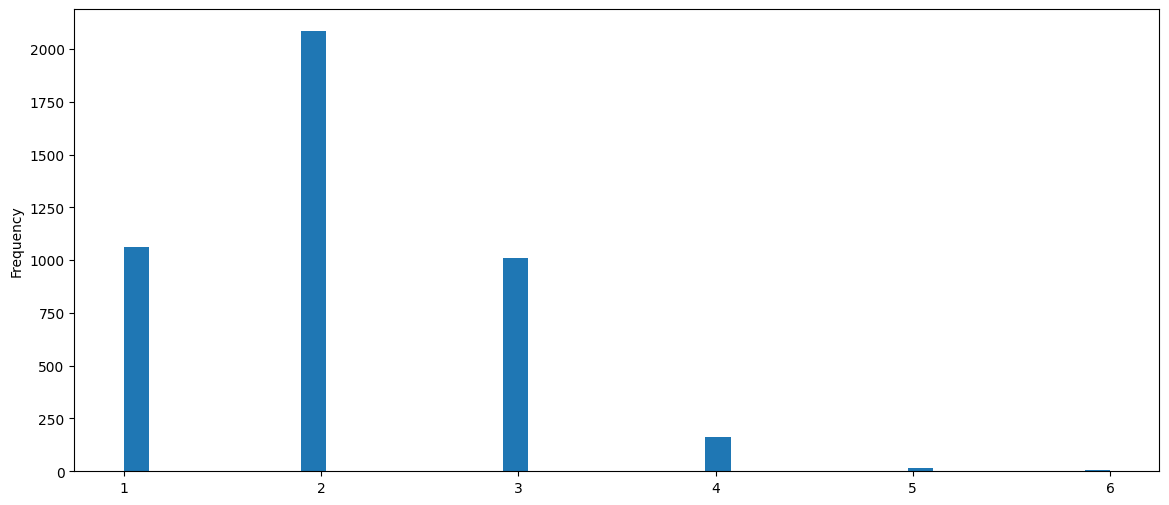

In [ ]:
ax = df['BHK'].plot(kind='hist',    # тип діаграми hist
                             bins=39,        # кількість стовпчиків
                             figsize=(14,6)  # розмір зображення(в дюймах)
                             )

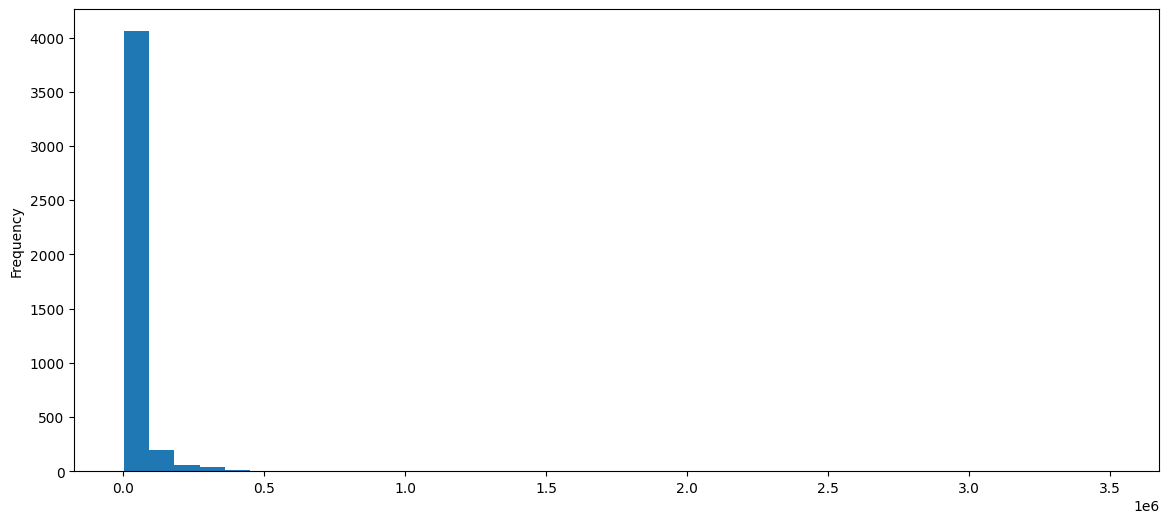

In [ ]:
ax = df['Rent'].plot(kind='hist',    # тип діаграми hist
                             bins=39,        # кількість стовпчиків
                             figsize=(14,6)  # розмір зображення(в дюймах)
                             )

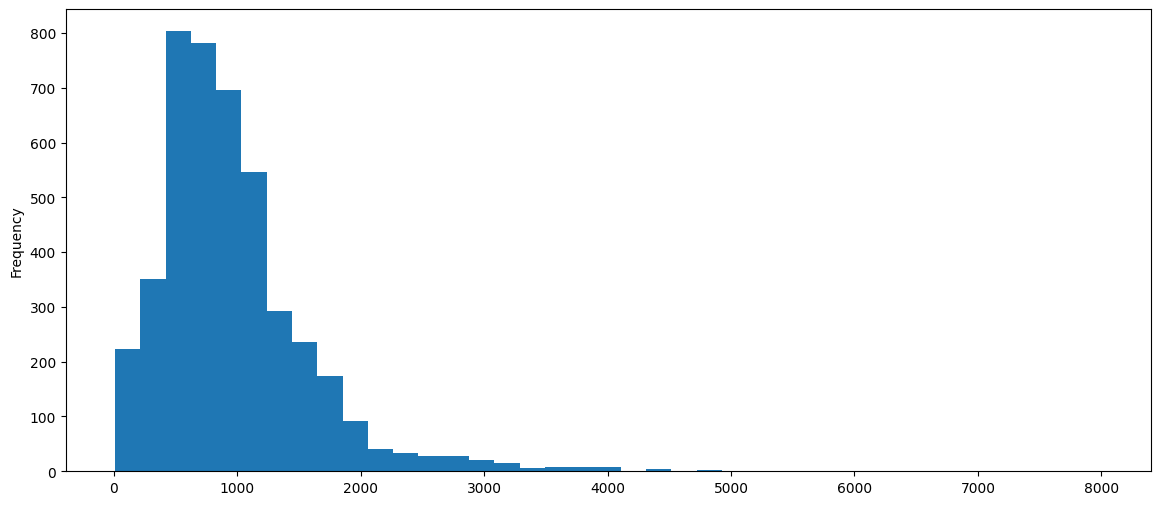

In [ ]:
ax = df['Size'].plot(kind='hist',    # тип діаграми hist
                             bins=39,        # кількість стовпчиків
                             figsize=(14,6)  # розмір зображення(в дюймах)
                             )

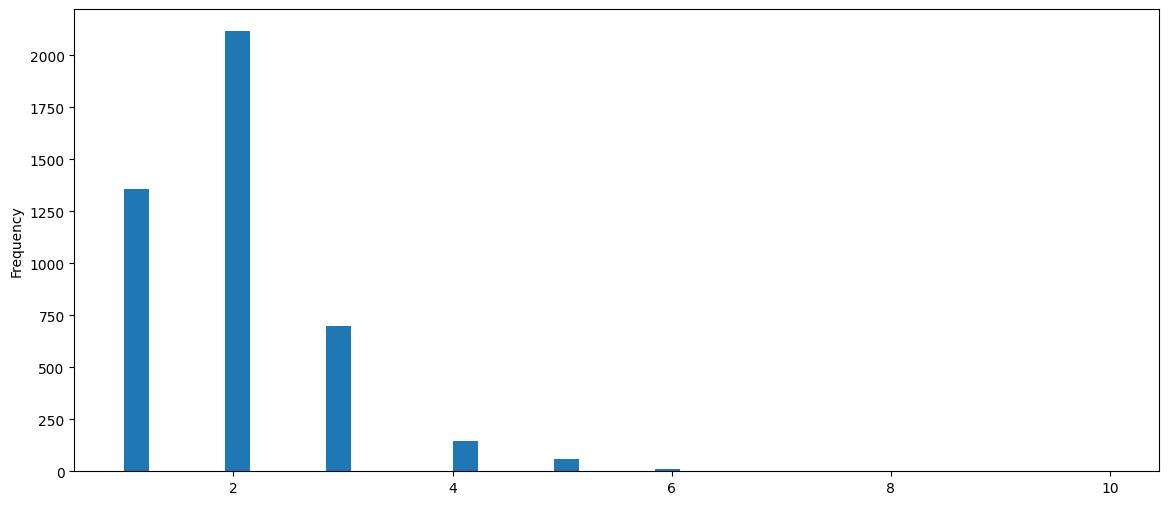

In [ ]:
ax = df['Bathroom'].plot(kind='hist',    # тип діаграми hist
                             bins=39,        # кількість стовпчиків
                             figsize=(14,6)  # розмір зображення(в дюймах)
                             )

# Завдання 3
Виведіть ящик з вусами для всіх числових стовпчиків. Де потрібно очистіть викиди

<Axes: >

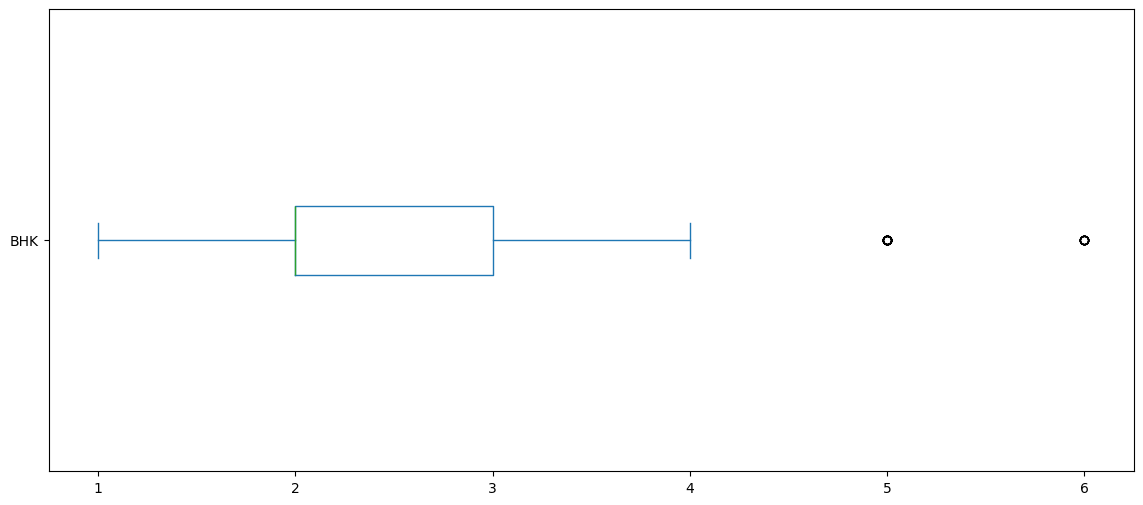

In [ ]:
df['BHK'].plot(kind='box', vert=False, figsize=(14,6))

<Axes: >

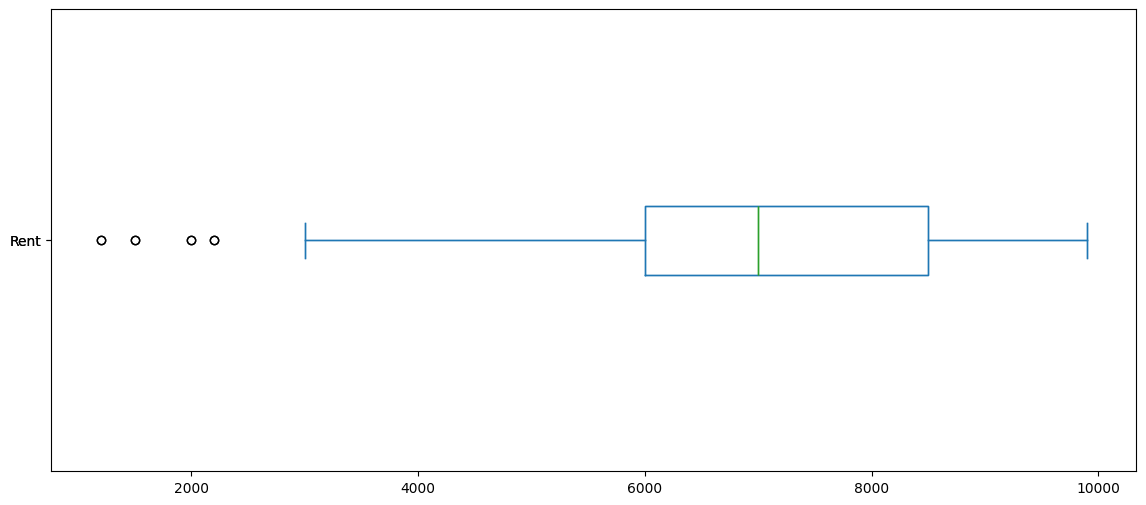

In [ ]:
df['Rent'].plot(kind='box', vert=False, figsize=(14,6))
mask = df['Rent'] < 10000
mask.sum()
df = df[mask]
df['Rent'].plot(kind='box', vert=False, figsize=(14,6))

<Axes: >

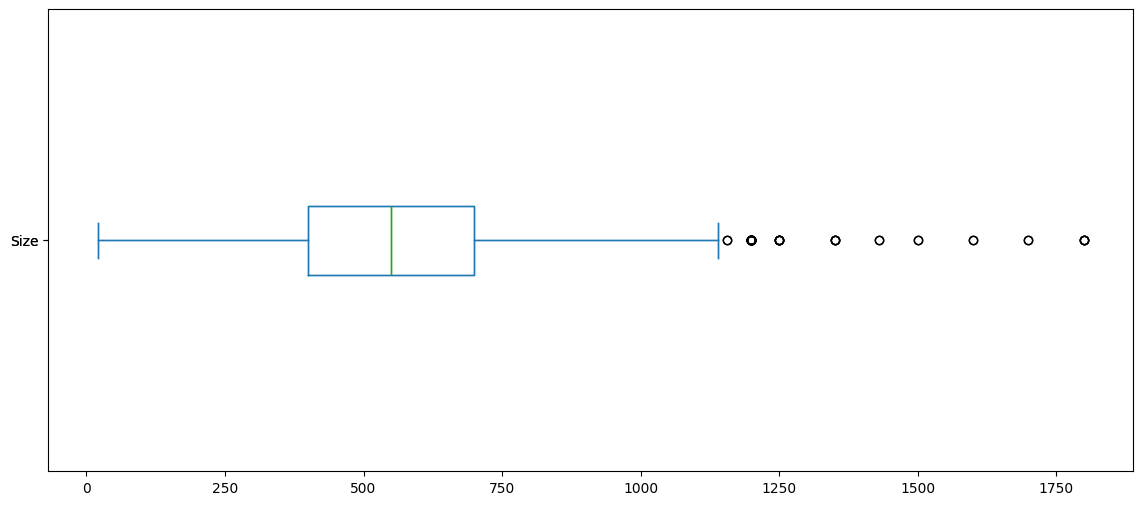

In [ ]:
df['Size'].plot(kind='box', vert=False, figsize=(14,6))
mask = df['Size'] < 2000
mask.sum()
df = df[mask]
df['Size'].plot(kind='box', vert=False, figsize=(14,6))

<Axes: >

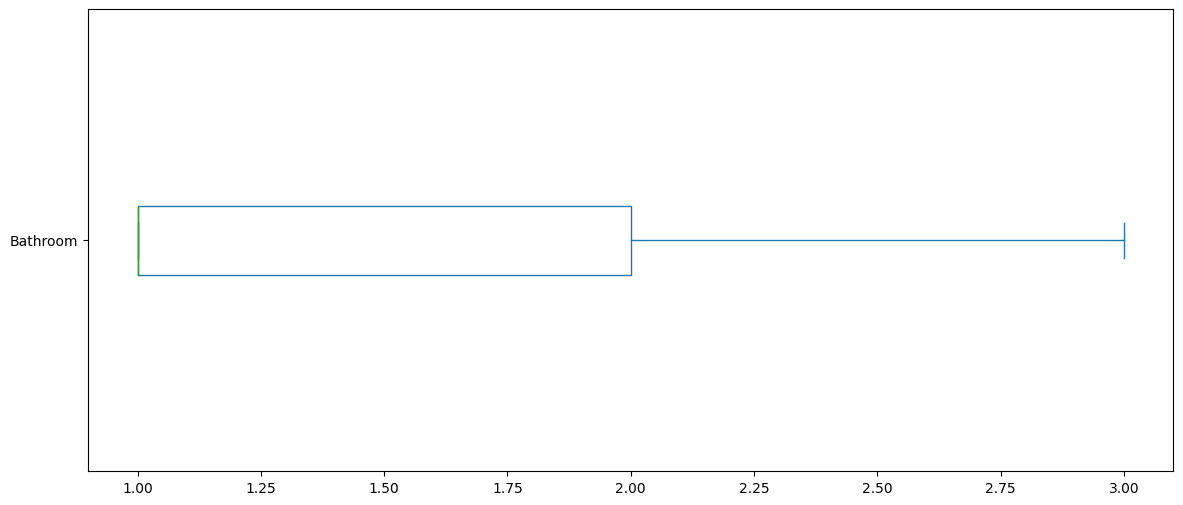

In [ ]:
df['Bathroom'].plot(kind='box', vert=False, figsize=(14,6))

# Завдання 4
Створіть Pipeline для обробки даних

In [ ]:
def clean_missing(df): # для NaN
    return df.dropna(subset=['Rent', 'Size'])

def convert_types(df): # проверка числовых типов
    df['Posted On'] = pd.to_datetime(df['Posted On'], errors='coerce')
    df['Rent'] = pd.to_numeric(df['Rent'], errors='coerce')
    df['Size'] = pd.to_numeric(df['Size'], errors='coerce')
    return df

def parse_floor(df): # взять данные этажа
    df['Floor_num'] = df['Floor'].str.extract(r'(\d+)').astype(float)
    return df

def add_features(df): # для отношения аренды к размеру
    df['Rent_per_sqft'] = df['Rent'] / df['Size']
    return df

def remove_outliers(df): # чистка данных
    return df[df['Rent'] < 10000]

df_clean = (
    df
    .pipe(clean_missing)
    .pipe(convert_types)
    .pipe(parse_floor)
    .pipe(add_features)
    .pipe(remove_outliers)
)